# 주얼리 이커머스 Meta 광고 성과 구조 분석
**어떤 운영 방식과 광고 소재가 Meta 광고 성과를 만드는가?**

---

## 프로젝트 개요

| 항목 | 내용 |
|------|------|
| 분석 대상 | 원석팔찌·커플세트 주얼리 이커머스 A사 |
| 분석 기간 | 2025.01.01 ~ 2025.12.31 (1년 전체) |
| 데이터 | Meta 광고 관리자 + 자사몰 주문 연계 데이터 |
| 운영 규모 | 캠페인 102 / 광고세트 128 / 광고 1,331 |

### 분석 목적
1. Meta 광고 알고리즘 최적화와 관련된 **비효율 구간 발견**
2. 실제 성과를 만드는 **메시지·소재 전략 도출**
3. 재현 가능한 **광고 운영 기준 수립**

### 주요 지표
- **ROAS** (Return On Ad Spend) = 매출 ÷ 광고비
- **CTR** (Click Through Rate) = 클릭 수 ÷ 노출 수

> ※ 기업 데이터 보호를 위해 구체 금액·캠페인명은 마스킹 처리되었습니다.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

print("라이브러리 로드 완료")

라이브러리 로드 완료


In [2]:
# 데이터 로드
ads_2025 = pd.read_csv('2025_meta_ads_daily_final.csv', encoding='utf-8-sig')
products = pd.read_csv('상품정보_20251030.csv', encoding='utf-8-sig')

# URL에서 product_no 추출 후 상품 정보 병합
ads_2025['product_no'] = pd.to_numeric(
    ads_2025['웹사이트 URL'].str.extract(r'/(\d+)/')[0], errors='coerce'
)
products['product_no'] = pd.to_numeric(products['product_no'], errors='coerce')
products = products.dropna(subset=['product_no'])

ads_df = pd.merge(
    ads_2025,
    products[['product_no', 'product_name']],
    on='product_no',
    how='left'
)

print(f"광고 데이터: {ads_df.shape[0]:,}행 × {ads_df.shape[1]}열")
print(f"분석 기간: {ads_df['일'].min()} ~ {ads_df['일'].max()}")

광고 데이터: 21,197행 × 40열
분석 기간: 2025-01-01 ~ 2025-12-31


---
## PART 1 — 광고 성과 구조 분석 (Performance)

> "성과를 만드는 운영 구조인가?"

Meta 광고는 7일 이후 약 50회 이상 전환이 발생하면 알고리즘 학습이 안정화된 상태(최적화)로 볼 수 있다.
이 기준으로 전체 광고를 **최적화 / 미최적화**로 분류하고, 광고 목적별(전환/트래픽)로 성과를 비교한다.

In [3]:
# 광고세트 수준 집계 및 최적화 분류
df = ads_df.copy()
df["일"] = pd.to_datetime(df["일"], errors="coerce")

# 숫자형 변환
num_cols = ["광고 기간","노출","도달","조회","결과","지출 금액 (KRW)",
            "링크 클릭","구매 전환값","구매","랜딩 페이지 조회"]
for col in num_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# 광고세트별 메타정보
adset_meta = df.groupby("광고 세트 ID", as_index=False).agg(
    성과_목표=("성과 목표","first"),
    결과_유형=("결과 유형","first"),
    product_name=("product_name","first")
)

# 7일 이상 구간에서 전환 집계
df_window = df[df["광고 기간"] >= 7].copy()
conv = df_window.groupby("광고 세트 ID", as_index=False).agg(
    purchases_7d=("구매","sum"),
    lpv_7d=("랜딩 페이지 조회","sum")
).merge(adset_meta, on="광고 세트 ID", how="left")

# 목적별 최적화 판정
conv["conv_7d"] = np.where(conv["성과_목표"]=="전환", conv["purchases_7d"], conv["lpv_7d"])
conv["optimization_status"] = np.where(conv["conv_7d"] >= 50, "최적화", "미최적화")

# 전체 광고세트에 최적화 여부 매핑
all_ids = pd.DataFrame({"광고 세트 ID": df["광고 세트 ID"].dropna().unique()})
opt_map = all_ids.merge(
    conv[["광고 세트 ID","conv_7d","optimization_status"]],
    on="광고 세트 ID", how="left"
)
opt_map["optimization_status"] = opt_map["optimization_status"].fillna("미최적화")

# 전체기간 광고세트 집계
ad_summary = df.groupby("광고 세트 ID", dropna=False).agg(
    impressions=("노출","sum"), reach=("도달","sum"),
    link_clicks=("링크 클릭","sum"), lpv=("랜딩 페이지 조회","sum"),
    purchases=("구매","sum"), purchase_value=("구매 전환값","sum"),
    spend=("지출 금액 (KRW)","sum"), results=("결과","sum"),
    ad_days=("광고 기간","max")
).reset_index()

ad_summary = ad_summary.merge(adset_meta, on="광고 세트 ID", how="left") \
                       .merge(opt_map, on="광고 세트 ID", how="left")

# 파생 지표
ad_summary["CTR"] = np.where(ad_summary["impressions"]>0,
    ad_summary["link_clicks"]/ad_summary["impressions"], np.nan)
ad_summary["ROAS"] = np.where(ad_summary["spend"]>0,
    ad_summary["purchase_value"]/ad_summary["spend"], np.nan)

# 광고 목적 그룹화
ad_summary["ad_goal"] = None
ad_summary.loc[ad_summary["성과_목표"]=="전환", "ad_goal"] = "구매"
ad_summary.loc[ad_summary["성과_목표"].isin(["링크 클릭","랜딩 페이지 조회"]), "ad_goal"] = "트래픽"
ad_summary = ad_summary.dropna(subset=["ad_goal"])

print(f"분석 대상 광고세트: {len(ad_summary)}개")
print(f"\n[최적화 상태 × 광고 목적별 분포]")
print(ad_summary.groupby(["ad_goal","optimization_status"]).size().unstack(fill_value=0))

분석 대상 광고세트: 124개

[최적화 상태 × 광고 목적별 분포]
optimization_status  미최적화  최적화
ad_goal                       
구매                     71   25
트래픽                     7   21


### 1-1. Meta 광고 최적화 현황

Meta 광고는 7일 이후 50회 전환 달성 시 알고리즘 학습이 안정화된다.
이 기준으로 **구매 광고의 74%가 미최적화** 상태임을 확인했다.

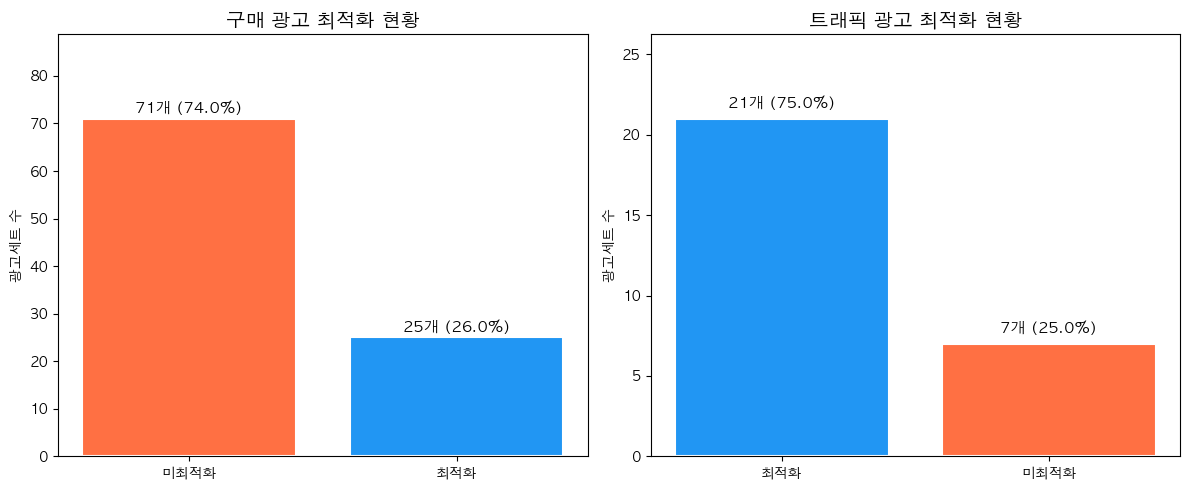

In [4]:
# 최적화 vs 미최적화 비교 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors = {'최적화': '#2196F3', '미최적화': '#FF7043'}

for i, goal in enumerate(['구매', '트래픽']):
    subset = ad_summary[ad_summary['ad_goal'] == goal]
    counts = subset['optimization_status'].value_counts()
    total = counts.sum()

    bars = axes[i].bar(counts.index, counts.values,
                       color=[colors.get(x, '#999') for x in counts.index],
                       edgecolor='white', linewidth=1.5)

    for bar, val in zip(bars, counts.values):
        pct = val / total * 100
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                     f'{val}개 ({pct:.1f}%)', ha='center', va='bottom', fontsize=11, fontweight='bold')

    axes[i].set_title(f'{goal} 광고 최적화 현황', fontsize=14, fontweight='bold')
    axes[i].set_ylabel('광고세트 수')
    axes[i].set_ylim(0, max(counts.values) * 1.25)

plt.tight_layout()
plt.show()

### 1-2. 미최적화 광고비 비중 분석

미최적화 광고는 개수 기준 74%이지만, **광고비 기준으로는 약 22%** 수준이다.
전체 예산의 약 22%가 학습 미달 상태에서 소진되었다.

[광고 목적별 미최적화 광고비 비중]
목적           최적화 비중      미최적화 비중      미최적화 비율
--------------------------------------------------
구매            74.3%        21.6%        22.6%
트래픽            3.9%         0.2%         4.8%

전체 미최적화 광고비 비중: 21.8%


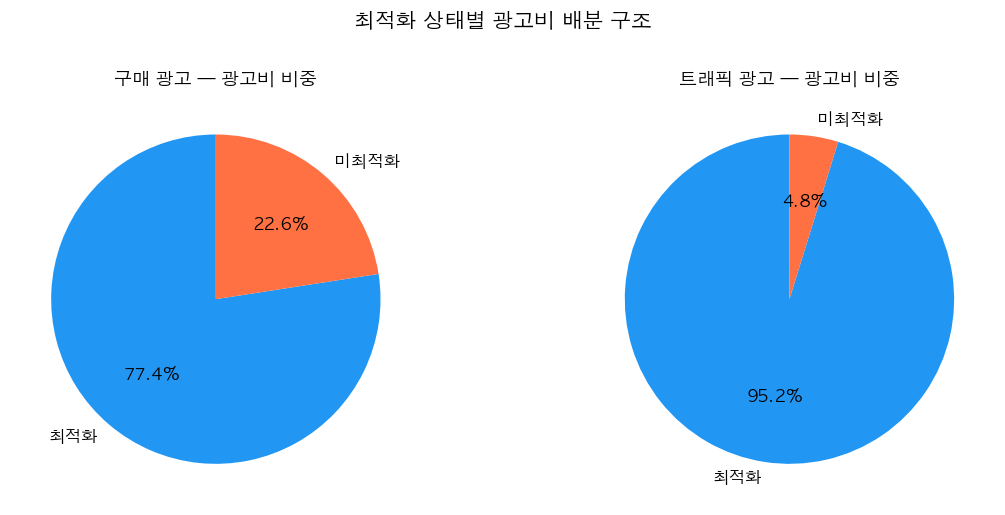

In [5]:
# 광고비 비중 분석
spend_by_group = ad_summary.groupby(["ad_goal", "optimization_status"])["spend"].sum().unstack(fill_value=0)
spend_by_group["total"] = spend_by_group.sum(axis=1)
spend_by_group["미최적화 비중(%)"] = (spend_by_group["미최적화"] / spend_by_group["total"] * 100).round(1)

# 비율로 표시 (마스킹)
spend_pct = spend_by_group.copy()
total_all = spend_pct["total"].sum()
for col in ["최적화", "미최적화", "total"]:
    spend_pct[f"{col}_pct"] = (spend_pct[col] / total_all * 100).round(1)

print("[광고 목적별 미최적화 광고비 비중]")
print(f"{'목적':<8} {'최적화 비중':>10} {'미최적화 비중':>12} {'미최적화 비율':>12}")
print("-" * 50)
for goal in spend_pct.index:
    opt_pct = spend_pct.loc[goal, "최적화_pct"]
    nopt_pct = spend_pct.loc[goal, "미최적화_pct"]
    nopt_ratio = spend_pct.loc[goal, "미최적화 비중(%)"]
    print(f"{goal:<8} {opt_pct:>9.1f}% {nopt_pct:>11.1f}% {nopt_ratio:>11.1f}%")

print(f"\n전체 미최적화 광고비 비중: {spend_by_group['미최적화'].sum()/spend_by_group['total'].sum()*100:.1f}%")

# 파이 차트
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i, goal in enumerate(["구매", "트래픽"]):
    if goal in spend_by_group.index:
        vals = [spend_by_group.loc[goal, "최적화"], spend_by_group.loc[goal, "미최적화"]]
        labels = ["최적화", "미최적화"]
        axes[i].pie(vals, labels=labels, autopct='%1.1f%%',
                    colors=['#2196F3', '#FF7043'], startangle=90,
                    textprops={'fontsize': 12})
        axes[i].set_title(f'{goal} 광고 — 광고비 비중', fontsize=13, fontweight='bold')

plt.suptitle('최적화 상태별 광고비 배분 구조', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 1-3. 잠재 광고 식별 — 조기 종료 광고 중 살릴 광고가 있는가?

7일 미만 조기 종료된 광고를 대상으로, **최적화 광고의 초기 성과 Q1(하위 25%)**과 비교하여
잠재력이 있는 광고를 식별한다.

→ 초기 3~6일 구매 5~8건 / ROAS 1.5+ 달성 시 **최소 7일 유지 권장**

구매 광고 — 최적화: 25개 / 미최적화: 71개
조기 종료 광고 (7일 미만): 15개

[최적화 광고 초기 성과 Q1 기준]
  구매 수 Q1: 71.0건
  ROAS Q1: 2.12


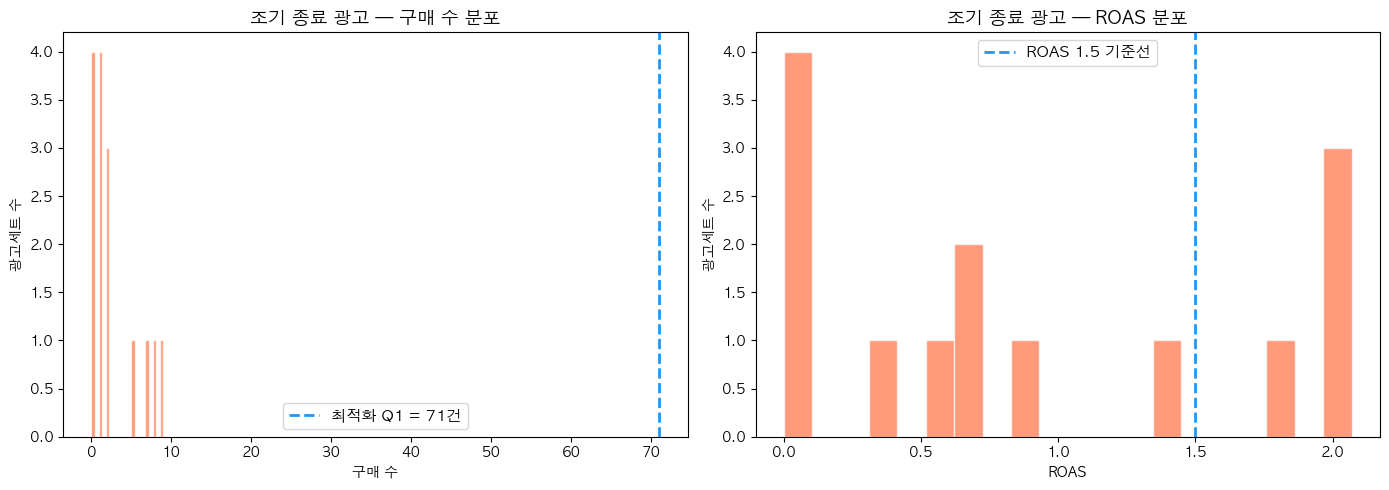


→ 잠재 광고 식별 기준: 초기 3~6일 구매 5~8건 이상 또는 ROAS 1.5 이상이면 최소 7일 유지 권장


In [6]:
# 잠재 광고 식별: 최적화 광고 Q1 기준 vs 조기 종료 광고
conv_ads = ad_summary[ad_summary['ad_goal'] == '구매'].copy()

optimized = conv_ads[conv_ads['optimization_status'] == '최적화']
not_optimized = conv_ads[conv_ads['optimization_status'] == '미최적화']

# 최적화 광고의 Q1 기준선
q1_purchases = optimized['purchases'].quantile(0.25)
q1_roas = optimized['ROAS'].quantile(0.25)

# 조기 종료 광고 (7일 미만)
early_stopped = not_optimized[not_optimized['ad_days'] < 7]
# 잠재 광고 (Q1 기준 이상 성과)
potential = early_stopped[
    (early_stopped['purchases'] >= q1_purchases * 0.3) |  # 초기이므로 더 낮은 기준
    (early_stopped['ROAS'] >= 1.5)
]

print(f"구매 광고 — 최적화: {len(optimized)}개 / 미최적화: {len(not_optimized)}개")
print(f"조기 종료 광고 (7일 미만): {len(early_stopped)}개")
print(f"\n[최적화 광고 초기 성과 Q1 기준]")
print(f"  구매 수 Q1: {q1_purchases:.1f}건")
print(f"  ROAS Q1: {q1_roas:.2f}")

# 시각화: 조기 종료 광고의 구매수 분포 vs 최적화 Q1
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 구매 수 분포
axes[0].hist(early_stopped['purchases'].dropna(), bins=20, color='#FF7043', alpha=0.7, edgecolor='white')
axes[0].axvline(q1_purchases, color='#2196F3', linestyle='--', linewidth=2, label=f'최적화 Q1 = {q1_purchases:.0f}건')
axes[0].set_title('조기 종료 광고 — 구매 수 분포', fontsize=13, fontweight='bold')
axes[0].set_xlabel('구매 수')
axes[0].set_ylabel('광고세트 수')
axes[0].legend(fontsize=11)

# ROAS 분포
roas_data = early_stopped['ROAS'].dropna()
roas_data = roas_data[roas_data < roas_data.quantile(0.95)]  # 극단값 제외
axes[1].hist(roas_data, bins=20, color='#FF7043', alpha=0.7, edgecolor='white')
axes[1].axvline(1.5, color='#2196F3', linestyle='--', linewidth=2, label='ROAS 1.5 기준선')
axes[1].set_title('조기 종료 광고 — ROAS 분포', fontsize=13, fontweight='bold')
axes[1].set_xlabel('ROAS')
axes[1].set_ylabel('광고세트 수')
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()

print(f"\n→ 잠재 광고 식별 기준: 초기 3~6일 구매 5~8건 이상 또는 ROAS 1.5 이상이면 최소 7일 유지 권장")

### 1-4. 비효율 광고 식별 — 최적화된 광고 중에서도 낭비되는 광고가 있는가?

학습 완료 광고 중에서도 **광고비↑ 성과↓인 4사분면 광고**를 식별한다.
광고비·ROAS(또는 CTR)의 중앙값을 기준으로 사분면을 나누어 비효율 구간을 진단한다.

[구매 광고] 4사분면(비효율) 광고: 8개 / 전체 최적화: 25개
[트래픽 광고] 4사분면(비효율) 광고: 6개 / 전체 최적화: 21개


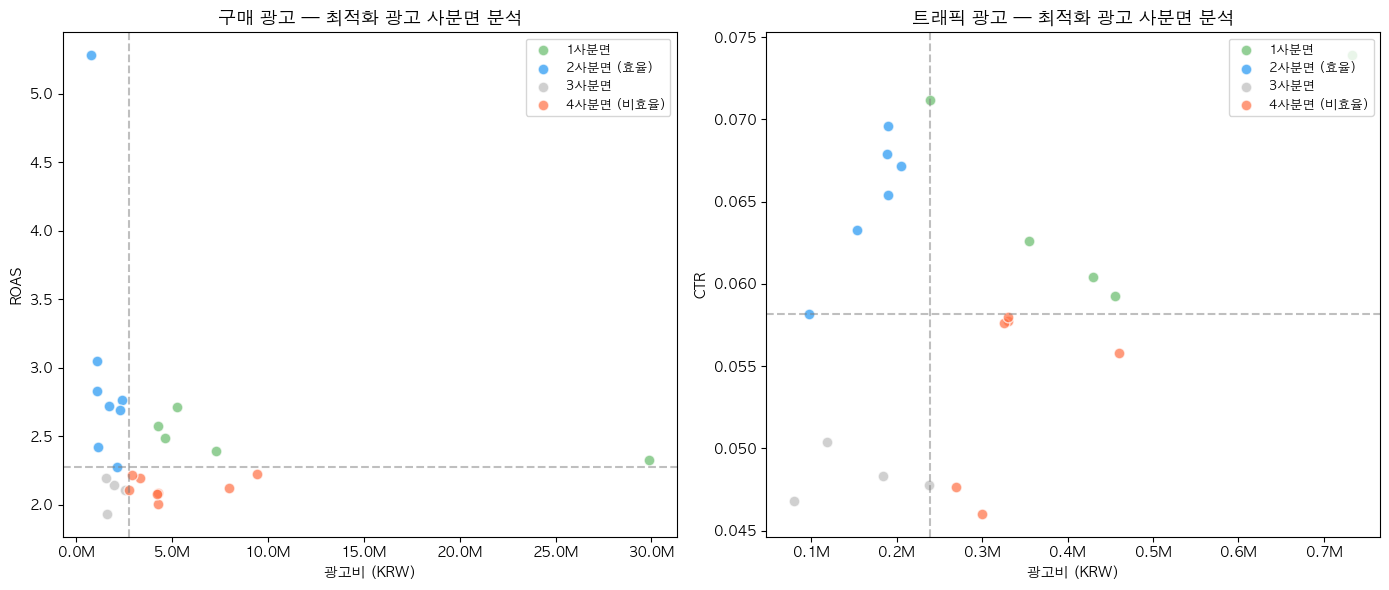


→ 4사분면 광고는 소재 교체 또는 예산 축소 대상
→ 비효율 예산을 2사분면(효율) 광고로 재배분 검토


In [7]:
# 사분면 분석: 최적화 광고 내 효율/비효율 구분
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for i, (goal, metric, label) in enumerate([
    ("구매", "ROAS", "ROAS"),
    ("트래픽", "CTR", "CTR")
]):
    subset = ad_summary[
        (ad_summary["ad_goal"] == goal) &
        (ad_summary["optimization_status"] == "최적화")
    ].copy()

    if len(subset) < 3:
        axes[i].text(0.5, 0.5, f'{goal} 광고 데이터 부족', ha='center', va='center')
        continue

    med_spend = subset["spend"].median()
    med_metric = subset[metric].median()

    # 사분면 분류
    def quadrant(row):
        if row["spend"] < med_spend and row[metric] >= med_metric:
            return "2사분면 (효율)"
        elif row["spend"] >= med_spend and row[metric] < med_metric:
            return "4사분면 (비효율)"
        elif row["spend"] >= med_spend and row[metric] >= med_metric:
            return "1사분면"
        else:
            return "3사분면"

    subset["quadrant"] = subset.apply(quadrant, axis=1)
    quad_colors = {
        "1사분면": "#66BB6A", "2사분면 (효율)": "#2196F3",
        "3사분면": "#BDBDBD", "4사분면 (비효율)": "#FF7043"
    }

    for q, color in quad_colors.items():
        q_data = subset[subset["quadrant"] == q]
        axes[i].scatter(q_data["spend"], q_data[metric],
                       c=color, label=q, s=60, alpha=0.7, edgecolors='white')

    axes[i].axvline(med_spend, color='gray', linestyle='--', alpha=0.5)
    axes[i].axhline(med_metric, color='gray', linestyle='--', alpha=0.5)
    axes[i].set_xlabel('광고비 (KRW)')
    axes[i].set_ylabel(label)
    axes[i].set_title(f'{goal} 광고 — 최적화 광고 사분면 분석', fontsize=13, fontweight='bold')
    axes[i].legend(fontsize=9, loc='upper right')
    axes[i].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x/1e6:.1f}M'))

    q4_count = len(subset[subset["quadrant"] == "4사분면 (비효율)"])
    print(f"[{goal} 광고] 4사분면(비효율) 광고: {q4_count}개 / 전체 최적화: {len(subset)}개")

plt.tight_layout()
plt.show()

print("\n→ 4사분면 광고는 소재 교체 또는 예산 축소 대상")
print("→ 비효율 예산을 2사분면(효율) 광고로 재배분 검토")

---
## PART 2 — 광고 콘텐츠 분석 (Content)

> "무엇이 성과를 만드는가?"

광고 본문 텍스트를 기준으로 키워드 기반 태깅을 수행하고,
메시지 유형별 성과 차이를 분석한다.

In [8]:
# 광고 단위 집계 (메시지 분석용)
import re

ad_level = df.groupby("광고 ID", as_index=False).agg({
    "광고 이름":"first", "캠페인 이름":"first", "광고 세트 이름":"first",
    "성과 목표":"first", "headline":"first", "설명":"first",
    "본문(광고 설정)":"first", "product_name":"first",
    "노출":"sum", "링크 클릭":"sum", "구매":"sum",
    "구매 전환값":"sum", "지출 금액 (KRW)":"sum", "랜딩 페이지 조회":"sum"
})

# 파생 지표
ad_level["CTR"] = ad_level["링크 클릭"] / ad_level["노출"]
ad_level["CVR"] = np.where(ad_level["링크 클릭"]>0, ad_level["구매"]/ad_level["링크 클릭"], 0)
ad_level["ROAS"] = np.where(ad_level["지출 금액 (KRW)"]>0,
    ad_level["구매 전환값"]/ad_level["지출 금액 (KRW)"], 0)

# 구매 발생 광고만 분석
purchase_ads = ad_level[ad_level["구매"] > 0].copy()

# 메시지 텍스트 결합
for col in ["headline","설명","본문(광고 설정)"]:
    purchase_ads[col] = purchase_ads[col].fillna("").astype(str)

purchase_ads["message_text"] = (
    purchase_ads["headline"].str.strip() + " " +
    purchase_ads["설명"].str.strip() + " " +
    purchase_ads["본문(광고 설정)"].str.strip()
).str.replace(r"\s+", " ", regex=True).str.strip()

# DPA 광고 제외 (템플릿 변수 포함)
purchase_ads = purchase_ads[~purchase_ads["message_text"].str.contains("{{", na=False)].copy()

print(f"구매 발생 광고 (DPA 제외): {len(purchase_ads)}개")

구매 발생 광고 (DPA 제외): 298개


### 2-1. 메시지 유형 분류

광고 메시지를 커뮤니케이션 목적에 따라 3가지로 분류한다:
- **의미형** (Meaning & Emotion): 선물, 의미, 행운, 관계 등 구매 동기 유도
- **제품 강조형** (Product Focused): 디자인, 소재, 착용 스타일 등 제품 정보 전달
- **이벤트형** (Event & Promotion): 할인, 증정, 시즌 이벤트 등 가격/혜택 강조

In [9]:
# 키워드 기반 자동 태깅
event_kw = ["할인","세일","특가","혜택","쿠폰","증정","이벤트","프로모션",
            "1+1","무료","한정","단독","사은품","특별가"]
product_kw = ["디자인","소재","원석","실버","골드","14k","18k","도금",
              "퀄리티","디테일","사이즈","착용","아이템","컬러",
              "고급스러운","스타일","룩"]
meaning_kw = ["선물","마음","의미","행운","소원","응원","위로","사랑","인연","행복",
              "성공","보호","부모","가족","추억","소중한","특별한","함께","전하세요",
              "당신에게","나를 위한","진심","감성","기념"]
strong_pairs = [["선물","행운"],["선물","마음"],["행운","가족"],
                ["응원","마음"],["사랑","선물"],["인연","행운"]]

def auto_tag(text):
    text = str(text).lower().strip()
    text = re.sub(r"\s+", " ", text)

    e_cnt = sum(kw.lower() in text for kw in event_kw)
    p_cnt = sum(kw.lower() in text for kw in product_kw)
    m_cnt = sum(kw.lower() in text for kw in meaning_kw)

    for pair in strong_pairs:
        if all(p.lower() in text for p in pair):
            return "의미형"
    if m_cnt >= 2: return "의미형"
    if e_cnt >= 1: return "이벤트형"
    if p_cnt >= 1: return "제품 강조형"
    if m_cnt >= 1: return "의미형"
    return "미분류"

purchase_ads["message_type"] = purchase_ads["message_text"].apply(auto_tag)

# 분류 결과
type_counts = purchase_ads["message_type"].value_counts()
print("[메시지 유형 분류 결과]")
for t, c in type_counts.items():
    print(f"  {t}: {c}개 ({c/len(purchase_ads)*100:.1f}%)")

[메시지 유형 분류 결과]


  의미형: 212개 (71.1%)
  제품 강조형: 44개 (14.8%)
  이벤트형: 42개 (14.1%)


### 2-2. 메시지 유형별 성과 비교

제품 강조형이 CTR·CVR·ROAS 전반적으로 **가장 높은 성과**를 보인다.
그러나 의미형이 전체 광고의 ~68%를 차지하므로, **의미형 내부 구조 개선이 핵심 레버**이다.

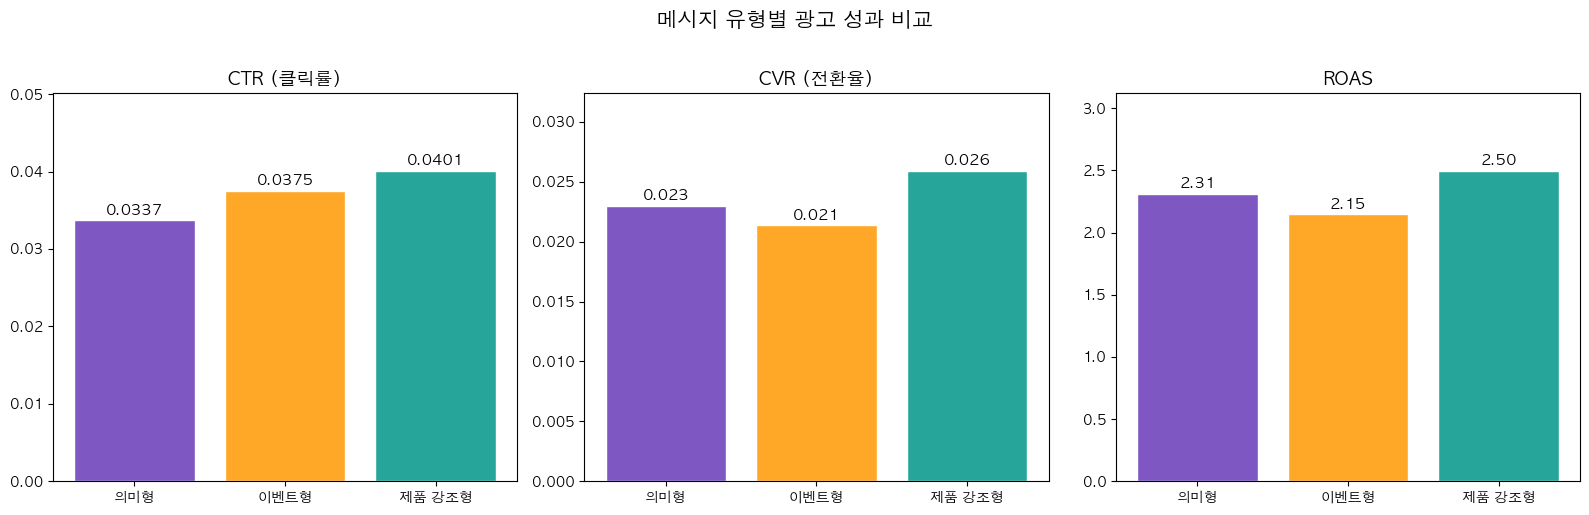


[메시지 유형별 광고비 · 매출 비중]
  의미형: 광고비 85.0% / 매출 84.6% / ROAS 2.31
  이벤트형: 광고비 4.9% / 매출 4.6% / ROAS 2.15
  제품 강조형: 광고비 10.1% / 매출 10.8% / ROAS 2.50


In [10]:
# 메시지 유형별 성과 집계
msg_perf = purchase_ads.groupby("message_type").agg(
    광고수=("광고 ID","nunique"),
    노출합=("노출","sum"),
    클릭합=("링크 클릭","sum"),
    구매합=("구매","sum"),
    매출합=("구매 전환값","sum"),
    광고비합=("지출 금액 (KRW)","sum")
).reset_index()

msg_perf["CTR"] = msg_perf["클릭합"] / msg_perf["노출합"]
msg_perf["CVR"] = msg_perf["구매합"] / msg_perf["클릭합"]
msg_perf["ROAS"] = msg_perf["매출합"] / msg_perf["광고비합"]
msg_perf["광고비 비중(%)"] = (msg_perf["광고비합"] / msg_perf["광고비합"].sum() * 100).round(1)
msg_perf["매출 비중(%)"] = (msg_perf["매출합"] / msg_perf["매출합"].sum() * 100).round(1)

# 미분류 제외
msg_perf_display = msg_perf[msg_perf["message_type"] != "미분류"].copy()

# 시각화
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
bar_colors = {"의미형": "#7E57C2", "제품 강조형": "#26A69A", "이벤트형": "#FFA726"}
types = msg_perf_display["message_type"].tolist()
colors = [bar_colors.get(t, "#999") for t in types]

for i, (metric, title) in enumerate([("CTR","CTR (클릭률)"), ("CVR","CVR (전환율)"), ("ROAS","ROAS")]):
    bars = axes[i].bar(types, msg_perf_display[metric], color=colors, edgecolor='white')
    axes[i].set_title(title, fontsize=13, fontweight='bold')
    for bar, val in zip(bars, msg_perf_display[metric]):
        fmt = f'{val:.4f}' if metric == "CTR" else f'{val:.3f}' if metric == "CVR" else f'{val:.2f}'
        axes[i].text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.02,
                     fmt, ha='center', fontsize=11, fontweight='bold')
    axes[i].set_ylim(0, msg_perf_display[metric].max() * 1.25)

plt.suptitle('메시지 유형별 광고 성과 비교', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# 광고비 vs 매출 기여
print("\n[메시지 유형별 광고비 · 매출 비중]")
for _, row in msg_perf_display.iterrows():
    print(f"  {row['message_type']}: 광고비 {row['광고비 비중(%)']:.1f}% / 매출 {row['매출 비중(%)']:.1f}% / ROAS {row['ROAS']:.2f}")

### 2-3. 의미형 메시지 심층 분석 (관계 vs 감정)

의미형 메시지를 **관계 기반**(COUPLE, GIFT, FAMILY, SELF)과 **감정/상징**(HAPPINESS, LUCK, LOVE 등)으로 세분류한다.

핵심 발견:
- 나(SELF)보다 **타인(관계) 지향** 메시지가 성과 우수
- **행복(HAPPINESS)** 메시지가 ROAS 최고, 행운(LUCK)은 상대적 저효율

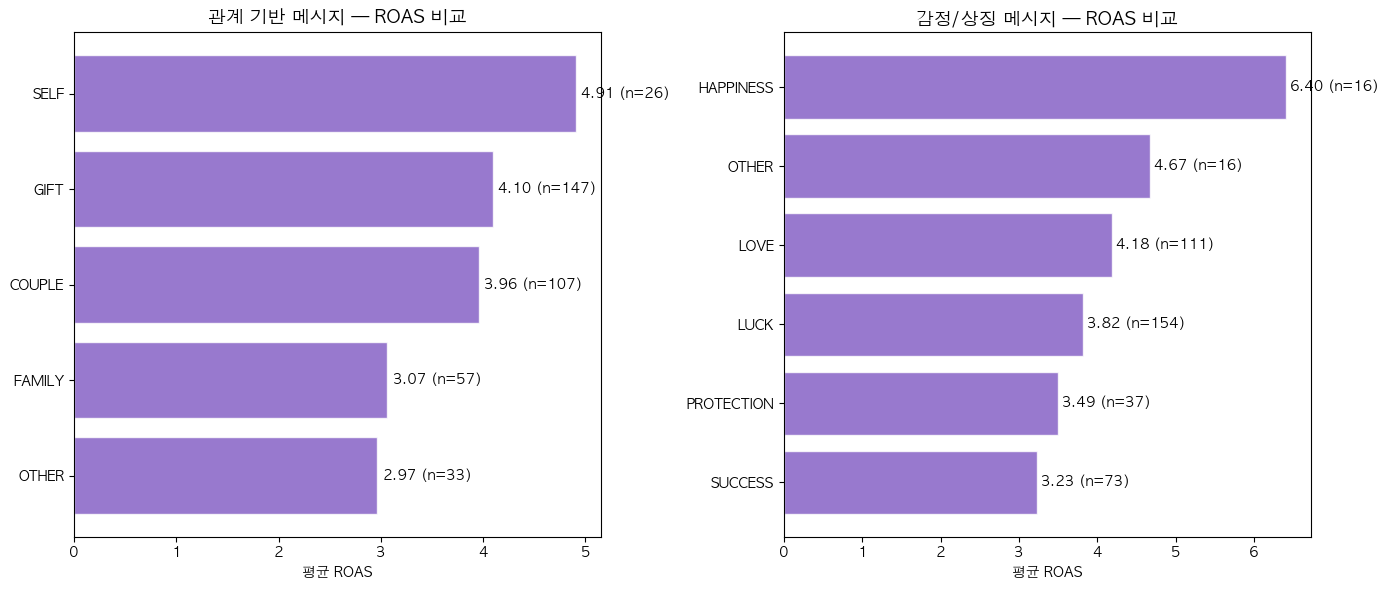

In [11]:
# 의미형 메시지 하위 분류
meaning_ads = purchase_ads[purchase_ads["message_type"] == "의미형"].copy()

# 관계 기반 태깅
relation_kw = {
    "COUPLE": ["커플","연인","우리"],
    "GIFT": ["선물","전하세요","드리세요"],
    "FAMILY": ["부모","가족","엄마","아빠","자식"],
    "SELF": ["나를 위한","나다운","나만의","자신"]
}

# 감정/상징 태깅
emotion_kw = {
    "HAPPINESS": ["행복","기쁨","미소","웃음"],
    "LUCK": ["행운","소원","운","부적"],
    "LOVE": ["사랑","인연","마음"],
    "PROTECTION": ["보호","지킴","수호"],
    "SUCCESS": ["성공","합격","응원"]
}

def tag_sub(text, keyword_dict):
    text = str(text).lower()
    tags = []
    for label, kws in keyword_dict.items():
        if any(kw in text for kw in kws):
            tags.append(label)
    return tags if tags else ["OTHER"]

meaning_ads["relation_tags"] = meaning_ads["message_text"].apply(lambda x: tag_sub(x, relation_kw))
meaning_ads["emotion_tags"] = meaning_ads["message_text"].apply(lambda x: tag_sub(x, emotion_kw))

# 관계 기반 성과
relation_rows = []
for _, row in meaning_ads.iterrows():
    for tag in row["relation_tags"]:
        relation_rows.append({"tag": tag, "ROAS": row["ROAS"], "CTR": row["CTR"], "spend": row["지출 금액 (KRW)"]})
relation_df = pd.DataFrame(relation_rows)

# 감정 기반 성과
emotion_rows = []
for _, row in meaning_ads.iterrows():
    for tag in row["emotion_tags"]:
        emotion_rows.append({"tag": tag, "ROAS": row["ROAS"], "CTR": row["CTR"], "spend": row["지출 금액 (KRW)"]})
emotion_df = pd.DataFrame(emotion_rows)

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for i, (data, title) in enumerate([
    (relation_df, "관계 기반 메시지 — ROAS 비교"),
    (emotion_df, "감정/상징 메시지 — ROAS 비교")
]):
    grouped = data.groupby("tag").agg(
        mean_roas=("ROAS","mean"),
        count=("ROAS","count")
    ).sort_values("mean_roas", ascending=True)

    # 최소 3개 이상인 태그만
    grouped = grouped[grouped["count"] >= 3]

    bars = axes[i].barh(grouped.index, grouped["mean_roas"],
                        color='#7E57C2', alpha=0.8, edgecolor='white')
    for bar, (idx, row) in zip(bars, grouped.iterrows()):
        axes[i].text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
                     f'{row["mean_roas"]:.2f} (n={int(row["count"])})',
                     va='center', fontsize=10)
    axes[i].set_title(title, fontsize=13, fontweight='bold')
    axes[i].set_xlabel('평균 ROAS')

plt.tight_layout()
plt.show()

### 2-4. 메시지 구조 전환 ROAS 시뮬레이션

행운(LUCK) 메시지 일부를 행복(HAPPINESS) 메시지로 전환했을 때의 ROAS 변화를 가중평균으로 시뮬레이션한다.

→ **추가 광고비 없이 메시지 구조 조정만으로 ROAS 개선 가능성 확인**

[현재 상태]
  LUCK 광고: 154개 (90.6%) — 평균 ROAS 3.82
  HAPPINESS 광고: 16개 (9.4%) — 평균 ROAS 6.40
  Baseline ROAS: 4.06

[LUCK → HAPPINESS 전환 시뮬레이션]
시나리오                         LUCK 비중    HAPPINESS 비중    예상 ROAS        개선율
---------------------------------------------------------------------------
AS-IS (현재)                     90.6%            9.4%      4.06      0.0%
STEP 1: 10% 전환                 81.8%           18.2%      4.29 +     5.6%
STEP 2: 30% 전환                 63.5%           36.5%      4.76 +    17.2%
STEP 3: 50% 전환                 45.3%           54.7%      5.23 +    28.8%


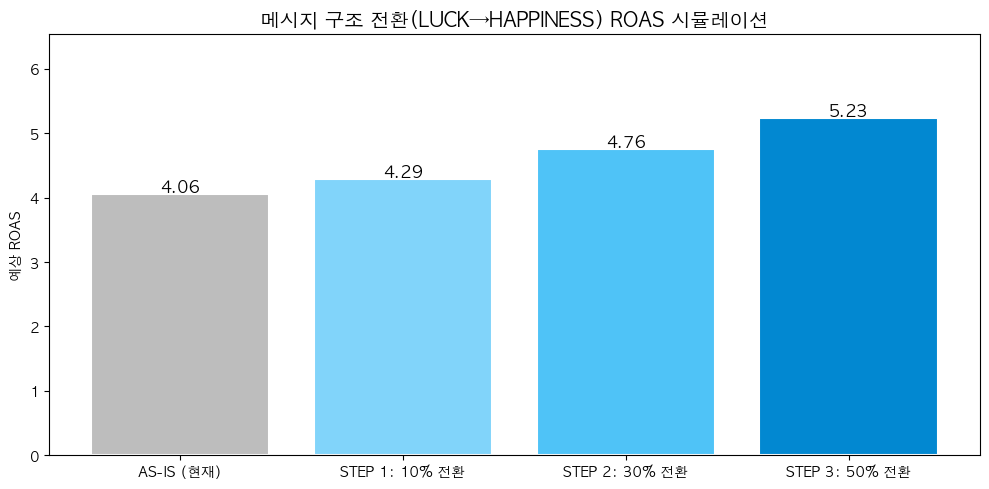


→ 메시지 구조 조정만으로 ROAS 최대 +28.8% 개선 가능


In [12]:
# LUCK vs HAPPINESS ROAS 시뮬레이션
luck_ads = meaning_ads[meaning_ads["emotion_tags"].apply(lambda x: "LUCK" in x)]
happy_ads = meaning_ads[meaning_ads["emotion_tags"].apply(lambda x: "HAPPINESS" in x)]

luck_roas = luck_ads["ROAS"].mean() if len(luck_ads) > 0 else 0
happy_roas = happy_ads["ROAS"].mean() if len(happy_ads) > 0 else 0
n_luck = len(luck_ads)
n_happy = len(happy_ads)
n_total = n_luck + n_happy

if n_total > 0:
    baseline_roas = (luck_roas * n_luck + happy_roas * n_happy) / n_total

    print(f"[현재 상태]")
    print(f"  LUCK 광고: {n_luck}개 ({n_luck/n_total*100:.1f}%) — 평균 ROAS {luck_roas:.2f}")
    print(f"  HAPPINESS 광고: {n_happy}개 ({n_happy/n_total*100:.1f}%) — 평균 ROAS {happy_roas:.2f}")
    print(f"  Baseline ROAS: {baseline_roas:.2f}")

    # 시뮬레이션 시나리오
    scenarios = [
        ("AS-IS (현재)", 0),
        ("STEP 1: 10% 전환", 0.10),
        ("STEP 2: 30% 전환", 0.30),
        ("STEP 3: 50% 전환", 0.50),
    ]

    print(f"\n[LUCK → HAPPINESS 전환 시뮬레이션]")
    print(f"{'시나리오':<25} {'LUCK 비중':>10} {'HAPPINESS 비중':>15} {'예상 ROAS':>10} {'개선율':>10}")
    print("-" * 75)

    sim_roas_list = []
    for name, shift in scenarios:
        new_luck_pct = (n_luck / n_total) * (1 - shift)
        new_happy_pct = 1 - new_luck_pct - (1 - n_luck/n_total - n_happy/n_total)
        sim_roas = luck_roas * new_luck_pct + happy_roas * new_happy_pct + baseline_roas * (1 - new_luck_pct - new_happy_pct)

        # 더 정확한 가중평균 계산
        shifted_n = int(n_luck * shift)
        new_n_luck = n_luck - shifted_n
        new_n_happy = n_happy + shifted_n
        sim_roas = (luck_roas * new_n_luck + happy_roas * new_n_happy) / n_total
        improvement = (sim_roas / baseline_roas - 1) * 100

        sim_roas_list.append(sim_roas)
        print(f"{name:<25} {new_n_luck/n_total*100:>9.1f}% {new_n_happy/n_total*100:>14.1f}% {sim_roas:>9.2f} {'+' if improvement > 0 else ''}{improvement:>8.1f}%")

    # 시각화
    fig, ax = plt.subplots(figsize=(10, 5))
    labels = [s[0] for s in scenarios]
    colors_sim = ['#BDBDBD', '#81D4FA', '#4FC3F7', '#0288D1']
    bars = ax.bar(labels, sim_roas_list, color=colors_sim, edgecolor='white', linewidth=1.5)

    for bar, val in zip(bars, sim_roas_list):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.03,
                f'{val:.2f}', ha='center', fontsize=12, fontweight='bold')

    ax.set_title('메시지 구조 전환(LUCK→HAPPINESS) ROAS 시뮬레이션', fontsize=14, fontweight='bold')
    ax.set_ylabel('예상 ROAS')
    ax.set_ylim(0, max(sim_roas_list)*1.25)
    plt.tight_layout()
    plt.show()

    print(f"\n→ 메시지 구조 조정만으로 ROAS 최대 +{(sim_roas_list[-1]/sim_roas_list[0]-1)*100:.1f}% 개선 가능")
else:
    print("LUCK/HAPPINESS 태그 데이터 부족")

### 2-5. 소재 유형별 분석 + 핵심 타겟 소재 전략

소재를 4가지로 확장 분류하여 분석:
- **제품효익**: 소재, 기능, 스펙 강조
- **관계상황**: 선물 대상, TPO 제시
- **콘텐츠표현**: 감성 무드, 후기 활용
- **프로모션**: 할인, 이벤트 강조

핵심 타겟인 **35~54세 여성**(매출 61.6%)에서는 소재별 역할을 구분하여 활용하는 것이 효과적이다.

[소재 유형별 성과]
          소재 수  평균 ROAS  평균 CTR     소재당 평균매출
의미 강조형   819.0   1.2685  0.0351  253529.2344
디자인 강조형  637.0   1.7237  0.0328  224742.6750
시즌 캠페인형  225.0   2.0163  0.0324  103390.7556
혜택 강조형   487.0   1.3453  0.0321   67556.7433


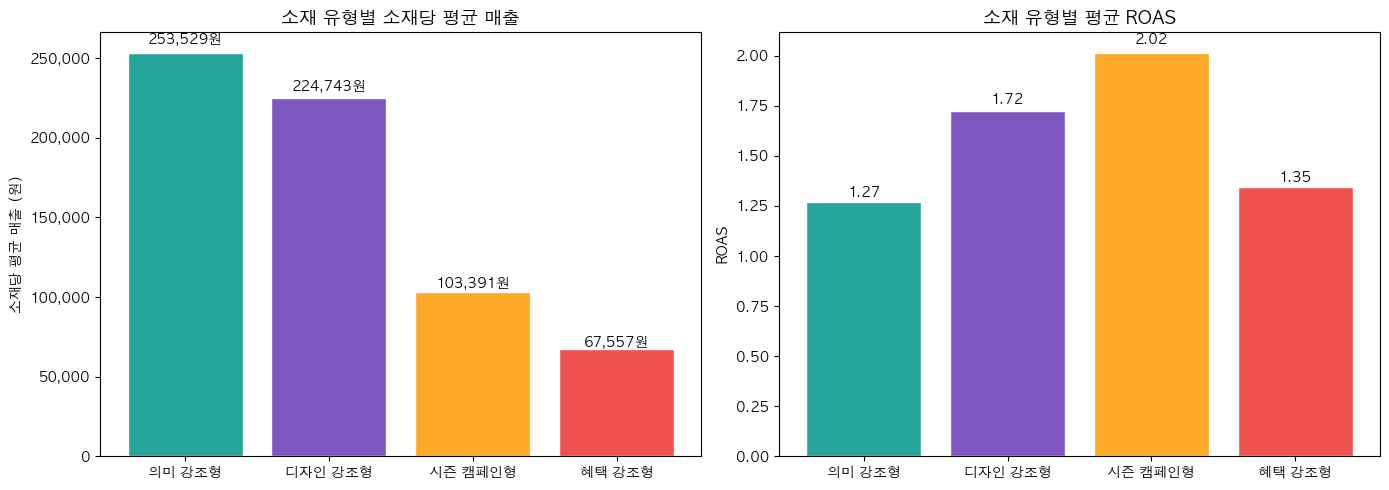

In [13]:
# 소재 확장 분류 (ads_tagged.csv 활용)
try:
    tagged = pd.read_csv('ads_tagged.csv', encoding='utf-8-sig')

    # 소재 유형별 성과
    tag_cols = ["tag_의미 강조형","tag_디자인 강조형","tag_혜택 강조형","tag_시즌 캠페인형"]

    tag_perf = {}
    for col in tag_cols:
        if col in tagged.columns:
            subset = tagged[tagged[col] == 1]
            if len(subset) > 0:
                name = col.replace("tag_","")
                tag_perf[name] = {
                    "소재 수": len(subset),
                    "평균 ROAS": subset["roas_calc"].mean(),
                    "평균 CTR": subset["ctr_link_calc"].mean(),
                    "광고비 합": subset["spend_krw"].sum(),
                    "매출 합": subset["purchase_value"].sum()
                }

    tag_df = pd.DataFrame(tag_perf).T
    tag_df["소재당 평균매출"] = tag_df["매출 합"] / tag_df["소재 수"]
    tag_df = tag_df.sort_values("소재당 평균매출", ascending=False)

    print("[소재 유형별 성과]")
    print(tag_df[["소재 수","평균 ROAS","평균 CTR","소재당 평균매출"]].round(4).to_string())

    # 시각화
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    colors_tag = ['#26A69A','#7E57C2','#FFA726','#EF5350']

    # 소재당 평균매출
    bars1 = axes[0].bar(tag_df.index, tag_df["소재당 평균매출"],
                        color=colors_tag[:len(tag_df)], edgecolor='white')
    axes[0].set_title('소재 유형별 소재당 평균 매출', fontsize=13, fontweight='bold')
    axes[0].set_ylabel('소재당 평균 매출 (원)')
    axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x:,.0f}'))
    for bar, val in zip(bars1, tag_df["소재당 평균매출"]):
        axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.02,
                     f'{val:,.0f}원', ha='center', fontsize=10, fontweight='bold')

    # ROAS 비교
    bars2 = axes[1].bar(tag_df.index, tag_df["평균 ROAS"],
                        color=colors_tag[:len(tag_df)], edgecolor='white')
    axes[1].set_title('소재 유형별 평균 ROAS', fontsize=13, fontweight='bold')
    axes[1].set_ylabel('ROAS')
    for bar, val in zip(bars2, tag_df["평균 ROAS"]):
        axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.02,
                     f'{val:.2f}', ha='center', fontsize=10, fontweight='bold')

    plt.tight_layout()
    plt.show()

except FileNotFoundError:
    print("ads_tagged.csv 파일을 찾을 수 없습니다.")

### 2-6. 제품별 최적 소재 차이

전체 광고 소재의 91.7%가 **원석팔찌 + 커플세트**에 집중되어 있다.
두 제품의 최적 소재 전략은 상이하다:
- **원석팔찌**: 제품 가치·효익 중심 소재 → 전환 우수
- **커플세트**: 감성 스토리·관계 중심 소재 → ROAS 압도적

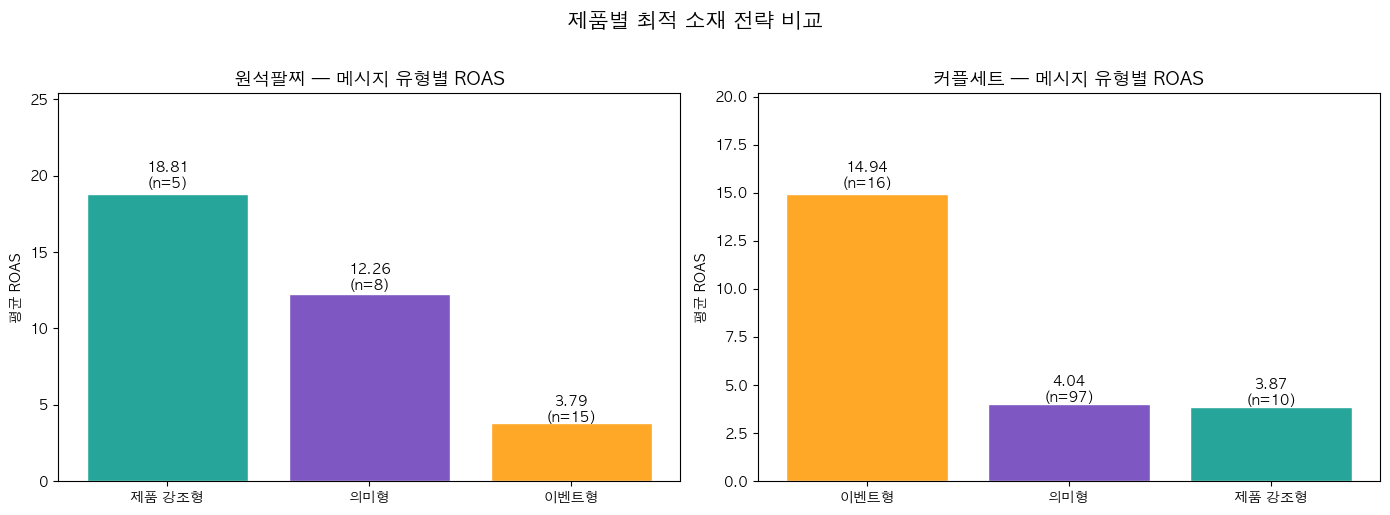


[제품 비중] 원석팔찌+커플세트 = 151개 (50.7%)


In [14]:
# 제품별 소재 성과 비교
product_ads = purchase_ads.copy()

# 제품 카테고리 분류
def categorize_product(name):
    if pd.isna(name):
        return "기타"
    name = str(name).lower()
    if any(kw in name for kw in ["팔찌","bracelet","원석"]):
        return "원석팔찌"
    elif any(kw in name for kw in ["커플","couple","세트"]):
        return "커플세트"
    else:
        return "기타"

product_ads["product_category"] = product_ads["product_name"].apply(categorize_product)

# 주력 제품만 필터
main_products = product_ads[product_ads["product_category"].isin(["원석팔찌","커플세트"])]

# 제품 × 메시지 유형별 ROAS
prod_msg = main_products.groupby(["product_category","message_type"]).agg(
    count=("광고 ID","nunique"),
    mean_roas=("ROAS","mean"),
    mean_ctr=("CTR","mean")
).reset_index()

prod_msg = prod_msg[prod_msg["message_type"] != "미분류"]
prod_msg = prod_msg[prod_msg["count"] >= 3]

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
bar_colors_msg = {"의미형":"#7E57C2", "제품 강조형":"#26A69A", "이벤트형":"#FFA726"}

for i, product in enumerate(["원석팔찌", "커플세트"]):
    subset = prod_msg[prod_msg["product_category"] == product].sort_values("mean_roas", ascending=False)
    colors_p = [bar_colors_msg.get(t,"#999") for t in subset["message_type"]]

    bars = axes[i].bar(subset["message_type"], subset["mean_roas"],
                       color=colors_p, edgecolor='white')
    for bar, (_, row) in zip(bars, subset.iterrows()):
        axes[i].text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.02,
                     f'{row["mean_roas"]:.2f}\n(n={int(row["count"])})',
                     ha='center', fontsize=10, fontweight='bold')

    axes[i].set_title(f'{product} — 메시지 유형별 ROAS', fontsize=13, fontweight='bold')
    axes[i].set_ylabel('평균 ROAS')
    axes[i].set_ylim(0, subset["mean_roas"].max() * 1.35)

plt.suptitle('제품별 최적 소재 전략 비교', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# 제품 비중
prod_counts = product_ads["product_category"].value_counts()
total_main = prod_counts.get("원석팔찌",0) + prod_counts.get("커플세트",0)
print(f"\n[제품 비중] 원석팔찌+커플세트 = {total_main}개 ({total_main/len(product_ads)*100:.1f}%)")

---
## PART 3 — 결론 및 실행 로드맵

> "어떻게 실행할 것인가?"

### 광고 성과를 결정하는 3가지 요소

| 요소 | 핵심 발견 | 실행 방향 |
|------|----------|----------|
| **운영 구조** | 구매 광고 예산 22%가 미최적화 상태에서 소진 | 최적화 전/후 운영 기준 적용 |
| **콘텐츠 메시지** | 행복+관계 조합이 ROAS 최고 효율 | 성과 중심 메시지 비중 확대 |
| **타겟·맥락** | 35~54세 여성 매출 61.6%, 제품별 최적 소재 상이 | 맥락에 따른 소재 역할 분리 |

### 3단계 실행 로드맵

| 단계 | 시기 | 실행 항목 |
|------|------|----------|
| **1단계: 운영 기준 적용** | 즉시 | 조기 종료 방지 (구매 5~8건/ROAS 1.5+ → 최소 7일 유지) |
| | | 비효율 광고 관리 (ROAS 2.2↓, CTR 6.0%↓ → 소재 교체/예산 축소) |
| **2단계: 테스트 & 재배분** | 1개월 내 | 비효율 예산 → 2사분면 + 제품 강조형 소재로 이동 |
| | | HAPPINESS A/B 테스트 실행 |
| | | 제품 강조형 비중 13% → 30% 확대 |
| **3단계: 성과 확대** | 3개월 내 | 검증된 승자(Winner) 소재에 예산 공격적 증액 |
| | | ROAS/CTR 임계값 상향 조정 |
| | | 주간 비효율 점검 및 소재 교체 루틴 정착 |

> **"조기 종료 방지 → 비효율 관리 → 성과 메시지 확대"의 선순환 구조를 만든다**